
Legend:
TN (True Negative): 2
FP (False Positive): 2
FN (False Negative): 2
TP (True Positive): 4


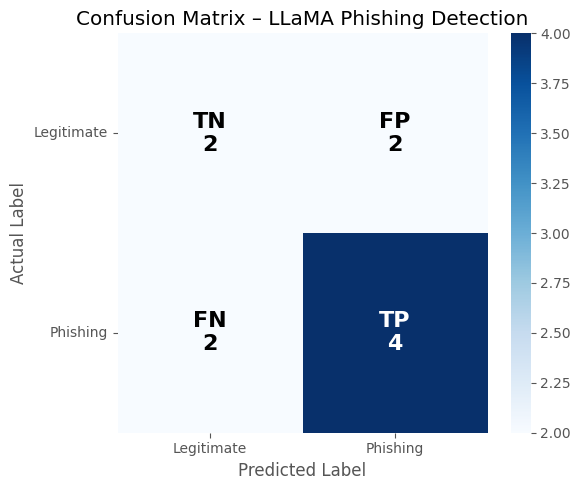


Evaluation Metrics:
Accuracy : 0.600
Precision: 0.667
Recall   : 0.667
F1 Score : 0.667


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# 1. Load the dataset
# -----------------------------
df = pd.read_csv("emails_with_verdict.csv")
y_true = df["is_phishing"]
y_pred = df["Llama verdict"]

# -----------------------------
# 2. Compute confusion matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nLegend:")
print("TN (True Negative):", tn)
print("FP (False Positive):", fp)
print("FN (False Negative):", fn)
print("TP (True Positive):", tp)

# -----------------------------
# 3. Plot confusion matrix with Seaborn
# -----------------------------
plt.figure(figsize=(6, 5))

# Create a mask for text color based on cell value
threshold = cm.max() / 2
text_colors = np.where(cm > threshold, "white", "black")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5, i + 0.5,
            f"{['TN','FP','FN','TP'][i*2+j]}\n{cm[i,j]}",
            ha='center',
            va='center',
            color=text_colors[i, j],
            fontsize=16,
            fontweight='bold'
        )

sns.heatmap(
    cm,
    annot=False,  # disable Seaborn annotation
    fmt='',
    cmap="Blues",
    cbar=True,
    linewidths=0
)

plt.title("Confusion Matrix – LLaMA Phishing Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0.5, 1.5], ["Legitimate", "Phishing"])
plt.yticks([0.5, 1.5], ["Legitimate", "Phishing"], rotation=0)

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Evaluation metrics
# -----------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nEvaluation Metrics:")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
